In [1]:
import os, sys, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
print(f"WD: {os.getcwd()}")

from src.data.loader import load_config, load_raw_data
config = load_config('configs/config.yaml')
df = load_raw_data(config)
print(df.shape)

WD: C:\Users\pc\Documents\credit-risk-scoring


2026-05-01 23:57:19,273 | INFO | Configuration chargée depuis configs/config.yaml
2026-05-01 23:57:19,283 | INFO | Chargement des données depuis data\raw\default of credit card clients.xls
2026-05-01 23:57:23,695 | INFO | Dataset chargé : 30000 lignes, 25 colonnes


(30000, 25)


=== Distribution de la target ===
Pas de défaut (0) : 23,364 (77.9%)
Défaut      (1) : 6,636 (22.1%)

Ratio déséquilibre : 1 défaut pour 3.5 non-défauts


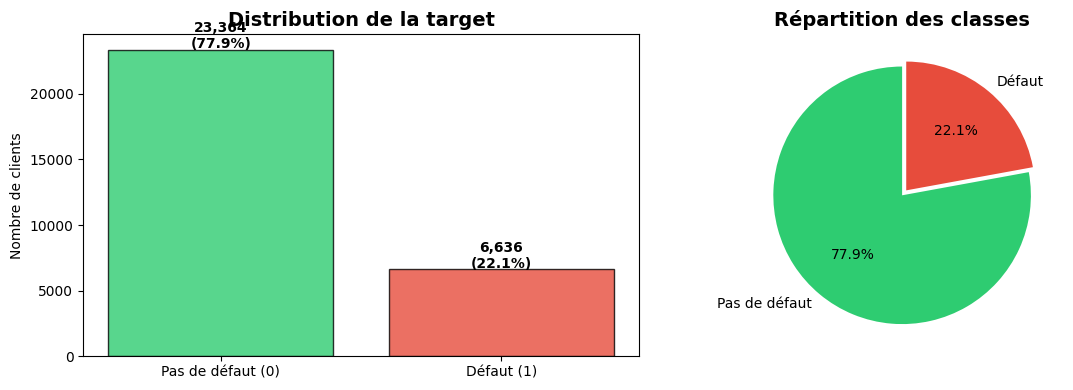

✅ Graphique sauvegardé


In [2]:
# Distribution de la target
target = 'default payment next month'

counts = df[target].value_counts()
pcts = df[target].value_counts(normalize=True) * 100

print("=== Distribution de la target ===")
print(f"Pas de défaut (0) : {counts[0]:,} ({pcts[0]:.1f}%)")
print(f"Défaut      (1) : {counts[1]:,} ({pcts[1]:.1f}%)")
print(f"\nRatio déséquilibre : 1 défaut pour {counts[0]/counts[1]:.1f} non-défauts")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Pas de défaut (0)', 'Défaut (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution de la target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({pcts[i]:.1f}%)',
                ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Pas de défaut', 'Défaut'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Répartition des classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé")

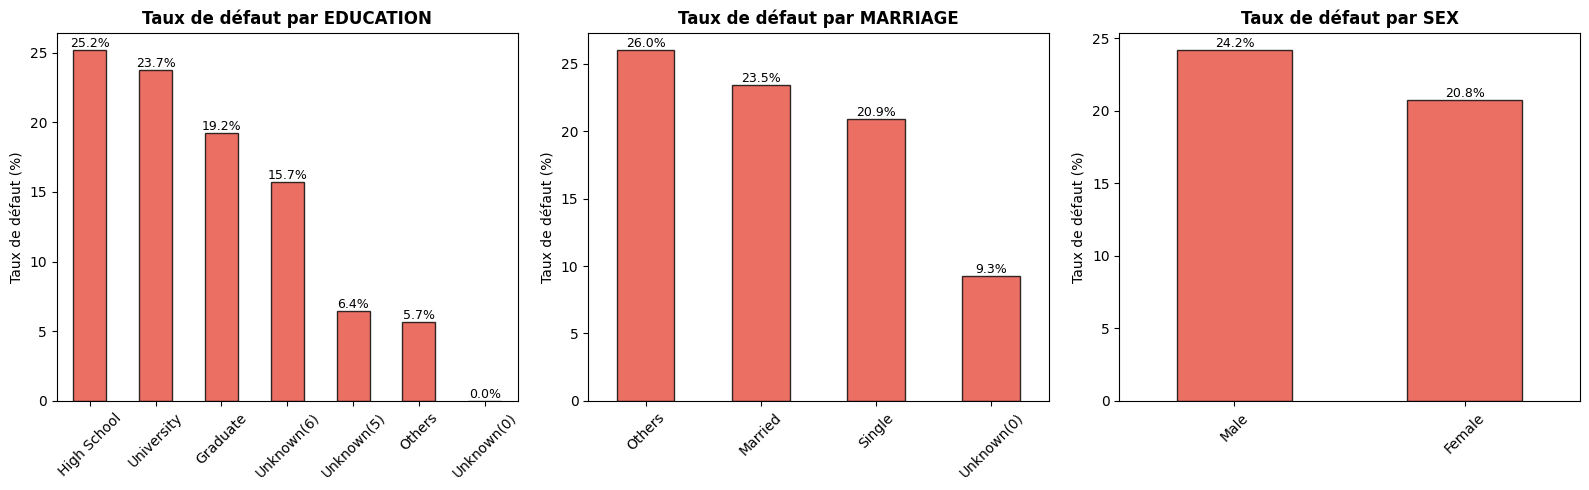

=== Taux de défaut par EDUCATION ===
EDUCATION
0     0.0
1    19.2
2    23.7
3    25.2
4     5.7
5     6.4
6    15.7
Name: default payment next month, dtype: float64

Valeurs uniques EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

=== Taux de défaut par MARRIAGE ===
MARRIAGE
0     9.3
1    23.5
2    20.9
3    26.0
Name: default payment next month, dtype: float64

Valeurs uniques MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [3]:
# Analyse des variables catégorielles par rapport à la target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_vars = {
    'EDUCATION': {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'},
    'MARRIAGE':  {1: 'Married', 2: 'Single', 3: 'Others'},
    'SEX':       {1: 'Male', 2: 'Female'}
}

for ax, (col, labels) in zip(axes, cat_vars.items()):
    # Taux de défaut par catégorie
    default_rate = df.groupby(col)['default payment next month'].mean() * 100
    default_rate.index = [labels.get(i, f'Unknown({i})') for i in default_rate.index]
    default_rate.sort_values(ascending=False).plot(
        kind='bar', ax=ax, color='#e74c3c', alpha=0.8, edgecolor='black'
    )
    ax.set_title(f'Taux de défaut par {col}', fontweight='bold')
    ax.set_ylabel('Taux de défaut (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('notebooks/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats texte
print("=== Taux de défaut par EDUCATION ===")
print(df.groupby('EDUCATION')['default payment next month'].mean().round(3) * 100)
print("\nValeurs uniques EDUCATION:", sorted(df['EDUCATION'].unique()))
print("\n=== Taux de défaut par MARRIAGE ===")
print(df.groupby('MARRIAGE')['default payment next month'].mean().round(3) * 100)
print("\nValeurs uniques MARRIAGE:", sorted(df['MARRIAGE'].unique()))

In [4]:
print("=== Comptage valeurs anormales EDUCATION ===")
print(df['EDUCATION'].value_counts().sort_index())
print(f"\nTotal anormaux (0,5,6) : {df['EDUCATION'].isin([0,5,6]).sum()}")
print(f"Pourcentage : {df['EDUCATION'].isin([0,5,6]).mean()*100:.2f}%")

print("\n=== Comptage valeurs anormales MARRIAGE ===")
print(df['MARRIAGE'].value_counts().sort_index())
print(f"\nTotal anormaux (0) : {(df['MARRIAGE']==0).sum()}")
print(f"Pourcentage : {(df['MARRIAGE']==0).mean()*100:.2f}%")

=== Comptage valeurs anormales EDUCATION ===
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Total anormaux (0,5,6) : 345
Pourcentage : 1.15%

=== Comptage valeurs anormales MARRIAGE ===
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Total anormaux (0) : 54
Pourcentage : 0.18%


In [5]:
from src.features.engineering import run_cleaning_pipeline

df_clean = run_cleaning_pipeline(df)

print(f"Shape : {df_clean.shape}")
print(f"Colonnes : {df_clean.columns.tolist()}")
print(f"\nEDUCATION valeurs : {sorted(df_clean['EDUCATION'].unique())}")
print(f"MARRIAGE valeurs  : {sorted(df_clean['MARRIAGE'].unique())}")
print(f"\nTarget : {df_clean['target'].value_counts().to_dict()}")

2026-05-01 23:57:27,034 | INFO | Démarrage du pipeline de nettoyage...
2026-05-01 23:57:27,056 | INFO | Colonne ID supprimée
2026-05-01 23:57:27,081 | INFO | EDUCATION nettoyé — valeurs uniques : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
2026-05-01 23:57:27,085 | INFO | MARRIAGE nettoyé — valeurs uniques : [np.int64(1), np.int64(2), np.int64(3)]
2026-05-01 23:57:27,110 | INFO | Target renommée : 'default payment next month' → 'target'
2026-05-01 23:57:27,165 | INFO | Features agrégées créées — shape : (30000, 17)
2026-05-01 23:57:27,167 | INFO | Pipeline terminé — shape final : (30000, 17)


Shape : (30000, 17)
Colonnes : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'target', 'BILL_AMT_MEAN', 'BILL_AMT_TREND', 'BILL_AMT_MAX', 'PAY_AMT_MEAN', 'PAY_RATIO']

EDUCATION valeurs : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE valeurs  : [np.int64(1), np.int64(2), np.int64(3)]

Target : {0: 23364, 1: 6636}


In [6]:
output_path = 'data/processed/clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Données sauvegardées : {output_path}")
print(f"   Shape : {df_clean.shape}")

✅ Données sauvegardées : data/processed/clean.csv
   Shape : (30000, 17)


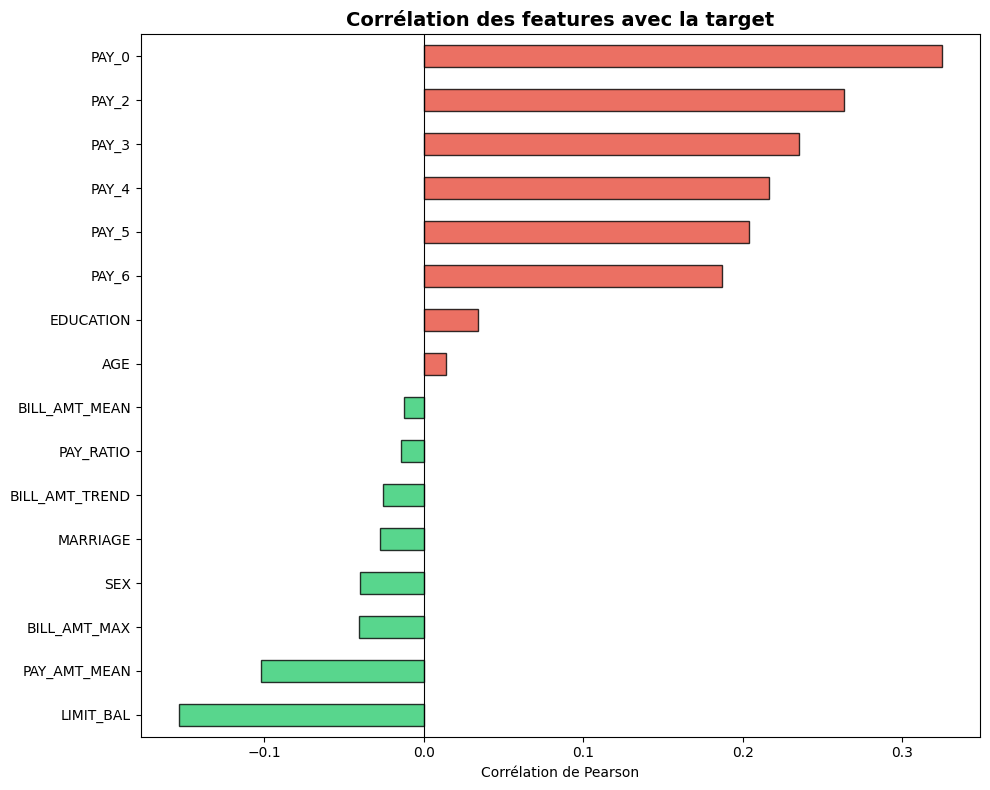

=== Top 5 features corrélées positivement (risque↑) ===
PAY_5    0.204
PAY_4    0.217
PAY_3    0.235
PAY_2    0.264
PAY_0    0.325
Name: target, dtype: float64

=== Top 5 features corrélées négativement (risque↓) ===
LIMIT_BAL      -0.154
PAY_AMT_MEAN   -0.102
BILL_AMT_MAX   -0.041
SEX            -0.040
MARRIAGE       -0.028
Name: target, dtype: float64


In [7]:
# Corrélations des features numériques avec la target
fig, ax = plt.subplots(figsize=(10, 8))

corr_with_target = df_clean.corr()['target'].drop('target').sort_values()

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.8)

ax.set_title('Corrélation des features avec la target', fontsize=14, fontweight='bold')
ax.set_xlabel('Corrélation de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('notebooks/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 features les plus corrélées
print("=== Top 5 features corrélées positivement (risque↑) ===")
print(corr_with_target.tail(5).round(3))
print("\n=== Top 5 features corrélées négativement (risque↓) ===")
print(corr_with_target.head(5).round(3))

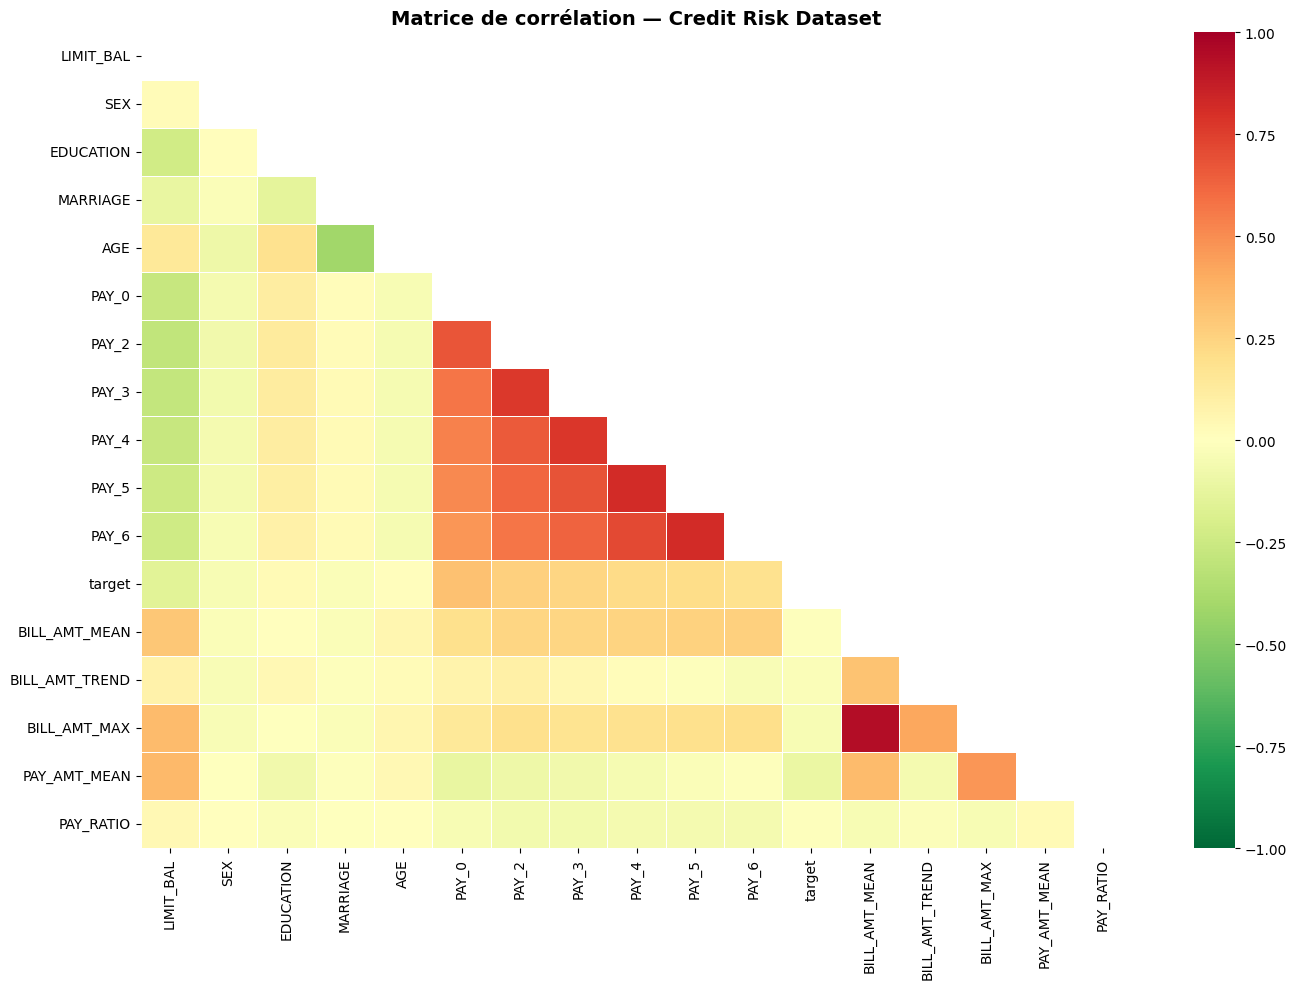

=== Paires de features fortement corrélées (>0.7) ===
  BILL_AMT_MEAN ↔ BILL_AMT_MAX : 0.944
  PAY_4 ↔ PAY_5 : 0.82
  PAY_5 ↔ PAY_6 : 0.817
  PAY_3 ↔ PAY_4 : 0.777
  PAY_2 ↔ PAY_3 : 0.767
  PAY_4 ↔ PAY_6 : 0.716


In [8]:
# Matrice de corrélation — features numériques uniquement
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df_clean.corr()

mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
import numpy as np
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask_upper, annot=False,
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5)

ax.set_title('Matrice de corrélation — Credit Risk Dataset',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations fortes entre features (multicolinéarité)
print("=== Paires de features fortement corrélées (>0.7) ===")
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            corr_pairs.append((corr_matrix.columns[i],
                              corr_matrix.columns[j], round(val, 3)))

for pair in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} ↔ {pair[1]} : {pair[2]}")

In [9]:
import os, sys
from pathlib import Path

# Toujours en premier dans chaque cellule après restart
os.chdir(Path.cwd().parent) if 'credit-risk-scoring' not in os.getcwd() else None
sys.path.insert(0, os.getcwd())

# Recharge le module après modification
import importlib
import src.features.engineering as eng
importlib.reload(eng)
from src.features.engineering import run_cleaning_pipeline
from src.data.loader import load_config, load_raw_data

config = load_config('configs/config.yaml')
df = load_raw_data(config)

df_clean = run_cleaning_pipeline(df)

print(f"Shape : {df_clean.shape}")
print(f"\nNouvelles features :")
new_features = ['BILL_AMT_MEAN', 'BILL_AMT_TREND',
                'BILL_AMT_MAX', 'PAY_AMT_MEAN', 'PAY_RATIO']
print(df_clean[new_features].describe().round(2))

2026-05-01 23:57:30,450 | INFO | Configuration chargée depuis configs/config.yaml
2026-05-01 23:57:30,453 | INFO | Chargement des données depuis data\raw\default of credit card clients.xls
2026-05-01 23:57:35,883 | INFO | Dataset chargé : 30000 lignes, 25 colonnes
2026-05-01 23:57:35,886 | INFO | Démarrage du pipeline de nettoyage...
2026-05-01 23:57:35,915 | INFO | Colonne ID supprimée
2026-05-01 23:57:35,936 | INFO | EDUCATION nettoyé — valeurs uniques : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
2026-05-01 23:57:35,978 | INFO | MARRIAGE nettoyé — valeurs uniques : [np.int64(1), np.int64(2), np.int64(3)]
2026-05-01 23:57:36,011 | INFO | Target renommée : 'default payment next month' → 'target'
2026-05-01 23:57:36,077 | INFO | Features agrégées créées — shape : (30000, 17)
2026-05-01 23:57:36,080 | INFO | Pipeline terminé — shape final : (30000, 17)


Shape : (30000, 17)

Nouvelles features :
       BILL_AMT_MEAN  BILL_AMT_TREND  BILL_AMT_MAX  PAY_AMT_MEAN  PAY_RATIO
count       30000.00        30000.00      30000.00      30000.00   30000.00
mean        44976.95        12351.57      60572.44       5275.23       0.47
std         63260.72        43922.42      78404.81      10137.95       5.51
min        -56043.17      -428791.00      -6029.00          0.00       0.00
25%          4781.33        -2963.00      10060.00       1113.29       0.04
50%         21051.83          923.00      31208.50       2397.17       0.08
75%         57104.42        19793.75      79599.00       5583.92       0.59
max        877313.83       708323.00    1664089.00     627344.33     797.00


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Séparer features et target
X = df_clean.drop(columns=['target'])
y = df_clean['target']

print(f"Features : {X.shape}")
print(f"Target   : {y.shape}")
print(f"Colonnes : {X.columns.tolist()}")

# Split train/test — stratifié pour préserver le ratio 78/22
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # ← important sur dataset déséquilibré
)

print(f"\nTrain : {X_train.shape} — défauts : {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape} — défauts : {y_test.mean()*100:.1f}%")

# Normalisation — StandardScaler
# On fit UNIQUEMENT sur le train, on transforme train ET test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Normalisation OK")
print(f"Mean avant scaling : {X_train['LIMIT_BAL'].mean():.0f}")
print(f"Mean après scaling : {X_train_scaled[:, 0].mean():.4f}")

Features : (30000, 16)
Target   : (30000,)
Colonnes : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT_MEAN', 'BILL_AMT_TREND', 'BILL_AMT_MAX', 'PAY_AMT_MEAN', 'PAY_RATIO']

Train : (24000, 16) — défauts : 22.1%
Test  : (6000, 16) — défauts : 22.1%

✅ Normalisation OK
Mean avant scaling : 167365
Mean après scaling : 0.0000
